# 3. A physics-guided baseline on metered buildings

A DR baseline has to predict consumption on the hottest days of the year, which are the days events are called. A model trained on spring data must then extrapolate beyond the temperatures it has seen. B5, the paper's physics-guided neural baseline, handles this by construction: its response to air temperature is a sum of softened hinge functions with non-negative weights, so it is monotone and convex in temperature, as chiller load is. Its calendar and humidity terms are learned freely.

This notebook repeats the paper's test on the 65 chilled-water meters at the Tempe (Arizona) site of the Building Data Genome Project 2. It covers a new facility with no summer history:

- every model is trained only on the 60 days before the season (spring 2017);
- the models are compared on the ten hottest summer weekdays, 14:00–18:00.

The test compares B5 with the committed time-of-week-and-temperature regression (B3) and with gradient-boosted trees (LightGBM).

**Data.** Run `python scripts/fetch_bdg2.py` once from `experiments/` (about 350 MB, checksummed). The notebook runs in about two minutes on four CPU cores. Neural training uses several threads, so the last digit can differ from the paper on another machine.

In [1]:
import os, pathlib, sys
if pathlib.Path.cwd().name == "notebooks":
    os.chdir("..")                      # data paths are relative to experiments/
sys.path.insert(0, ".")

import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dcflex import realdata, validate
from dcflex.style import PALETTE as C, apply_publication_style
%matplotlib inline
apply_publication_style()
plt.rcParams["figure.dpi"] = 110

# the numbers printed in the paper, written by run_all.py and run_ml.py
paper = pd.read_csv("../results/numbers.csv", index_col="macro", dtype=str)["value"]

def check(name, value):
    """Print a value computed here next to the number printed in the paper, at the paper's precision."""
    printed = paper[name]
    decimals = len(printed.split(".")[1]) if "." in printed else 0
    here = f"{value:.{decimals}f}"
    print(f"{name:26s} here {here:>8s}   paper {printed:>8s}   {'same' if here == printed else 'DIFFERENT'}")

In [2]:
p = realdata.site_panel("Fox", "chilledwater")          # BDG2 site "Fox" is Tempe, Arizona
train = p["pre"]                                           # the 60 days before the season
print(f"{len(p['buildings'])} chilled-water meters; training up to {np.nanmax(p['temp'][train]):.1f} °C, "
      f"summer up to {np.nanmax(p['temp'][p['season']]):.1f} °C")
check("RrdTempeChwMeters", len(p["buildings"]))
check("RrdTempeChwTrainTmax", np.nanmax(p["temp"][train]))
check("RrdTempeChwSeasonTmax", np.nanmax(p["temp"][p["season"]]))

65 chilled-water meters; training up to 41.7 °C, summer up to 48.3 °C
RrdTempeChwMeters          here       65   paper       65   same
RrdTempeChwTrainTmax       here     41.7   paper     41.7   same
RrdTempeChwSeasonTmax      here     48.3   paper     48.3   same


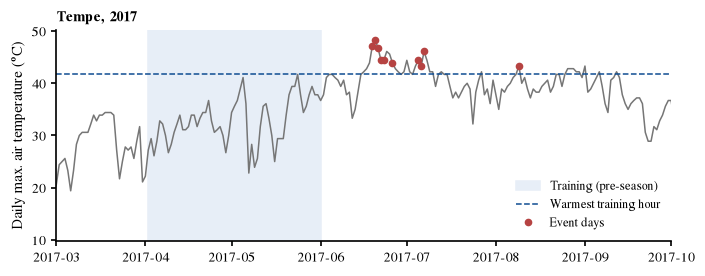

In [3]:
temp_day = pd.Series(p["temp"], index=p["idx"]).resample("D").max()
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.plot(temp_day.index, temp_day.values, color=C["grey_mid"], lw=1)
tr = pd.DatetimeIndex(p["idx"][train])
ax.axvspan(tr[0], tr[-1], color=C["blue_tint"], label="Training (pre-season)")
ax.axhline(np.nanmax(p["temp"][train]), color=C["blue_main"], ls="--", lw=1, label="Warmest training hour")
ev = [p["idx"][d * 24] for d in p["events"]]
ax.plot(ev, temp_day.reindex(pd.DatetimeIndex(ev).normalize()).values, "o", color=C["red_strong"], ms=4, label="Event days")
ax.set(ylabel="Daily max. air temperature (°C)", title="Tempe, 2017")
ax.set_xlim(pd.Timestamp("2017-03-01"), pd.Timestamp("2017-10-01"))
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

## Train on spring, predict the hottest days

Each model is fitted per meter. B5 is an ensemble of three seeds per meter, trained in vectorized batches.

In [4]:
q = validate.response_query(p)          # a weekday at 15:00, dew point at its summer median, 15–50 °C
pred, resp = {}, {}
t = time.time()
pred["B3 committed regression"], resp["B3 committed regression"] = validate.towt_committed(p, train, query=q)
pred["LightGBM"], resp["LightGBM"] = validate.gbm(p, train, query=q)
pred["B5 physics-guided"], _, resp["B5 physics-guided"] = validate.neural(p, train, "pgnb", seeds=(0, 1, 2),
                                                                         epochs=800, query=q)
print(f"trained in {time.time() - t:.0f} s")

scores = {m: validate.scores(p, P, train) for m, P in pred.items()}
pd.DataFrame({m: {"Event-day error, median (%)": np.nanmedian(s["event_nmae"]),
                  "Summer CV(RMSE), median (%)": np.nanmedian(s["season_cv"]),
                  "Summer bias, median (%)": np.nanmedian(s["season_nmbe"])} for m, s in scores.items()}).T.round(1)

trained in 197 s


,"Event-day error, median (%)","Summer CV(RMSE), median (%)","Summer bias, median (%)"
B3 committed regression,15.5,29.3,-16.4
LightGBM,21.6,30.4,-19.2
B5 physics-guided,9.7,29.2,-17.9


In [5]:
for m, tag in (("B5 physics-guided", "Bfive"), ("B3 committed regression", "Towt"), ("LightGBM", "Gbm")):
    check(f"RrdTempeChwEv{tag}", np.nanmedian(scores[m]["event_nmae"]))
    check(f"RrdTempeChwCv{tag}", np.nanmedian(scores[m]["season_cv"]))

RrdTempeChwEvBfive         here      9.7   paper      9.7   same
RrdTempeChwCvBfive         here     29.2   paper     29.2   same
RrdTempeChwEvTowt          here     15.5   paper     15.5   same
RrdTempeChwCvTowt          here     29.3   paper     29.3   same
RrdTempeChwEvGbm           here     21.6   paper     21.6   same
RrdTempeChwCvGbm           here     30.4   paper     30.4   same


All three models trained in spring underestimate the summer as a whole (the bias column): the load drifts over the season in ways that spring data do not show, which Appendix E of the paper discusses. On the event days that settlement uses, B5's physical structure makes the difference.

Why B5 wins on event days while matching the others over the whole summer: the learned response to temperature for the median meter, at 15:00 on a weekday. Beyond the warmest training hour, trees cannot extrapolate (LightGBM stays flat), and the regression extends its last linear segment, whose slope rests on a few warm spring days. B5's response keeps rising and curving upward, as chiller load does.

B5 response monotone: True | convex: True


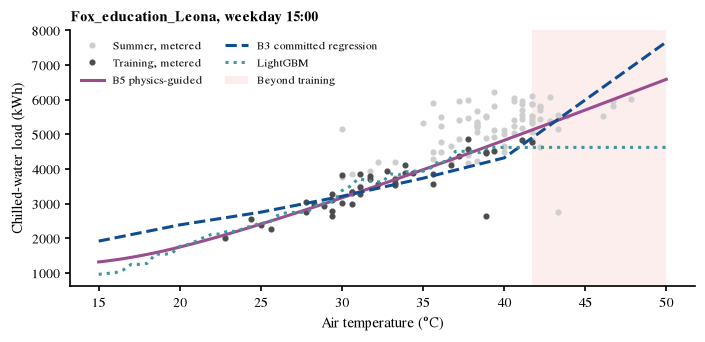

In [6]:
order = np.argsort(scores["B5 physics-guided"]["season_cv"])
j = order[len(order) // 2]                                  # the meter with the median B5 summer CV(RMSE)
at = (p["hour"] == 15) & (p["dow"] < 5)
style = {"B5 physics-guided": (C["violet"], "-"), "B3 committed regression": (C["blue_main"], "--"), "LightGBM": (C["teal"], ":")}

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(p["temp"][p["season"] & at], p["Y"][p["season"] & at, j], "o", color=C["neutral"], ms=3, label="Summer, metered")
ax.plot(p["temp"][train & at], p["Y"][train & at, j], "o", color=C["grey_dark"], ms=3, label="Training, metered")
for m, (col, ls) in style.items():
    ax.plot(q["temp"], resp[m][:, j], color=col, ls=ls, lw=2, label=m)
ax.axvspan(np.nanmax(p["temp"][train]), q["temp"].max(), color=C["red_1"], alpha=0.35, lw=0, label="Beyond training")
ax.set(xlabel="Air temperature (°C)", ylabel="Chilled-water load (kWh)", title=f"{p['buildings'][j]}, weekday 15:00")
ax.legend(fontsize=7.5, ncol=2, loc="upper left")
fig.tight_layout()

b5_curve = resp["B5 physics-guided"][:, j]
print("B5 response monotone:", bool(np.all(np.diff(b5_curve) >= -1e-9)),
      "| convex:", bool(np.all(np.diff(b5_curve, 2) >= -1e-6)))

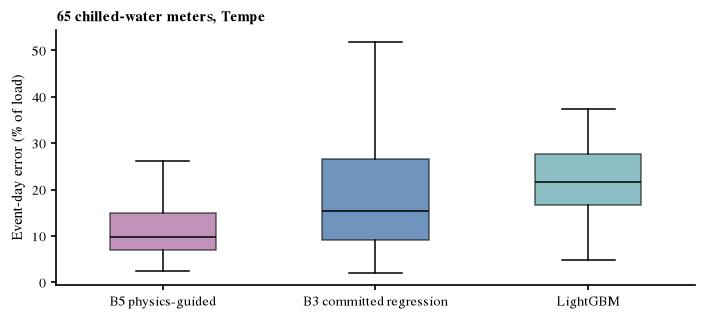

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.0))
errors = [scores[m]["event_nmae"][np.isfinite(scores[m]["event_nmae"])] for m in style]
bp = ax.boxplot(errors, widths=0.5, patch_artist=True, showfliers=False, medianprops=dict(color="black"))
for patch, (col, _) in zip(bp["boxes"], style.values()):
    patch.set(facecolor=col, alpha=0.6)
ax.set_xticks(range(1, len(style) + 1), list(style))
ax.set(ylabel="Event-day error (% of load)", title=f"{len(p['buildings'])} chilled-water meters, Tempe")
fig.tight_layout()

The paper repeats this test at Austin and Orlando, on electricity meters, for an established facility with a year of history, and with cross-building pretraining (`run_ml.py realdata`); Appendix E reports those results.